**New**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

latent_dim = 100
batch_size = 128
lr = 0.00005          
epochs = 50
image_size = 28 * 28


n_critic = 5        
clip_value = 0.01     

cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(-1, 1, 28, 28)
        return img

In [ ]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)

        )

    def forward(self, img):
        img = img.view(img.size(0), -1)
        out = self.model(img)
        return out

In [ ]:
generator = Generator(latent_dim).to(device)
critic    = Critic().to(device)

optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
optimizer_C = optim.RMSprop(critic.parameters(),    lr=lr)

In [6]:
def show_images(images, epoch):
    images = images.detach().cpu()
    grid = images[:25]

    fig, axs = plt.subplots(5, 5, figsize=(5, 5))
    idx = 0
    for i in range(5):
        for j in range(5):
            axs[i, j].imshow(grid[idx].squeeze(), cmap='gray')
            axs[i, j].axis('off')
            idx += 1

    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()

Epoch [1/50]  Critic Loss: -0.3590  Gen Loss: -0.1210
Epoch [2/50]  Critic Loss: -0.4748  Gen Loss: -0.5195
Epoch [3/50]  Critic Loss: -0.3821  Gen Loss: -0.5155
Epoch [4/50]  Critic Loss: -0.3602  Gen Loss: -0.1002
Epoch [5/50]  Critic Loss: -0.3962  Gen Loss: 0.1081
Epoch [6/50]  Critic Loss: -0.4910  Gen Loss: 0.4663
Epoch [7/50]  Critic Loss: -0.5351  Gen Loss: 0.5143
Epoch [8/50]  Critic Loss: -0.5524  Gen Loss: 0.5815
Epoch [9/50]  Critic Loss: -0.5456  Gen Loss: 0.5581
Epoch [10/50]  Critic Loss: -0.5330  Gen Loss: 0.5480


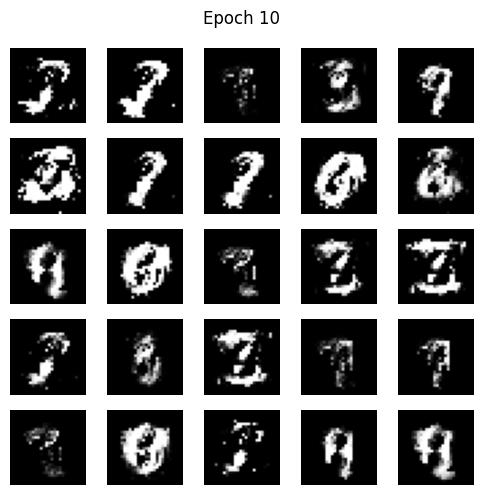

Epoch [11/50]  Critic Loss: -0.5223  Gen Loss: 0.5136
Epoch [12/50]  Critic Loss: -0.5147  Gen Loss: 0.5428
Epoch [13/50]  Critic Loss: -0.5032  Gen Loss: 0.5305
Epoch [14/50]  Critic Loss: -0.4797  Gen Loss: 0.5139
Epoch [15/50]  Critic Loss: -0.4448  Gen Loss: 0.4510
Epoch [16/50]  Critic Loss: -0.4182  Gen Loss: 0.4295
Epoch [17/50]  Critic Loss: -0.3854  Gen Loss: 0.4334
Epoch [18/50]  Critic Loss: -0.3619  Gen Loss: 0.3975
Epoch [19/50]  Critic Loss: -0.3348  Gen Loss: 0.3673
Epoch [20/50]  Critic Loss: -0.3186  Gen Loss: 0.3339


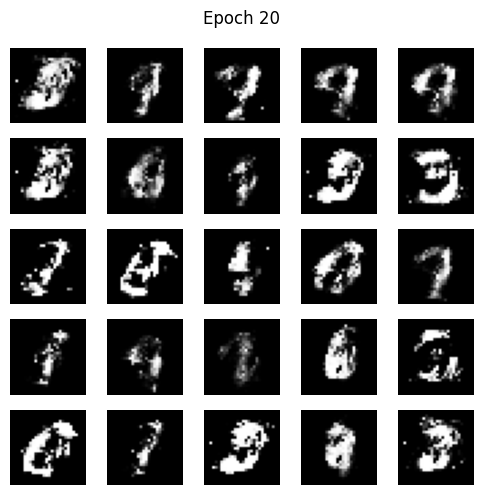

Epoch [21/50]  Critic Loss: -0.2982  Gen Loss: 0.2993
Epoch [22/50]  Critic Loss: -0.2861  Gen Loss: 0.2791
Epoch [23/50]  Critic Loss: -0.2651  Gen Loss: 0.2788
Epoch [24/50]  Critic Loss: -0.2510  Gen Loss: 0.2702
Epoch [25/50]  Critic Loss: -0.2393  Gen Loss: 0.2591
Epoch [26/50]  Critic Loss: -0.2240  Gen Loss: 0.2488
Epoch [27/50]  Critic Loss: -0.2131  Gen Loss: 0.2173
Epoch [28/50]  Critic Loss: -0.2022  Gen Loss: 0.2137
Epoch [29/50]  Critic Loss: -0.1966  Gen Loss: 0.2398
Epoch [30/50]  Critic Loss: -0.1827  Gen Loss: 0.2010


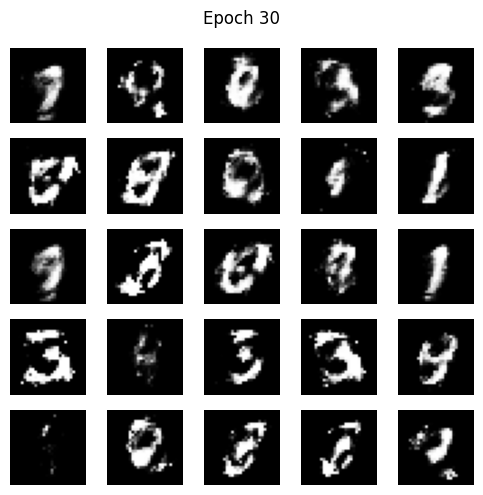

Epoch [31/50]  Critic Loss: -0.1798  Gen Loss: 0.2212
Epoch [32/50]  Critic Loss: -0.1762  Gen Loss: 0.2209
Epoch [33/50]  Critic Loss: -0.1715  Gen Loss: 0.2258
Epoch [34/50]  Critic Loss: -0.1655  Gen Loss: 0.2353
Epoch [35/50]  Critic Loss: -0.1667  Gen Loss: 0.2257
Epoch [36/50]  Critic Loss: -0.1602  Gen Loss: 0.2412
Epoch [37/50]  Critic Loss: -0.1559  Gen Loss: 0.2377
Epoch [38/50]  Critic Loss: -0.1505  Gen Loss: 0.2149
Epoch [39/50]  Critic Loss: -0.1447  Gen Loss: 0.2317
Epoch [40/50]  Critic Loss: -0.1424  Gen Loss: 0.2079


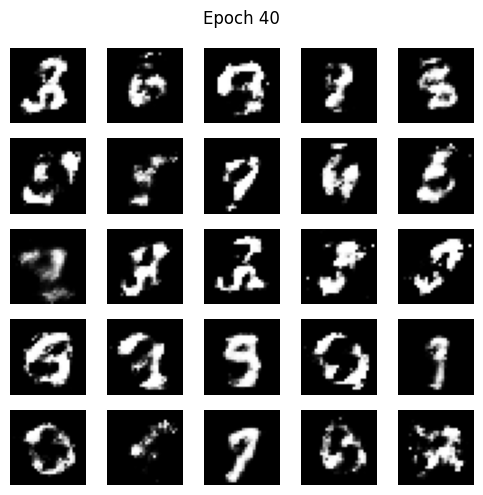

Epoch [41/50]  Critic Loss: -0.1391  Gen Loss: 0.2204
Epoch [42/50]  Critic Loss: -0.1318  Gen Loss: 0.1950
Epoch [43/50]  Critic Loss: -0.1294  Gen Loss: 0.2385
Epoch [44/50]  Critic Loss: -0.1322  Gen Loss: 0.2537
Epoch [45/50]  Critic Loss: -0.1263  Gen Loss: 0.2655
Epoch [46/50]  Critic Loss: -0.1255  Gen Loss: 0.2342
Epoch [47/50]  Critic Loss: -0.1225  Gen Loss: 0.2135
Epoch [48/50]  Critic Loss: -0.1240  Gen Loss: 0.2745
Epoch [49/50]  Critic Loss: -0.1199  Gen Loss: 0.2357
Epoch [50/50]  Critic Loss: -0.1198  Gen Loss: 0.2486


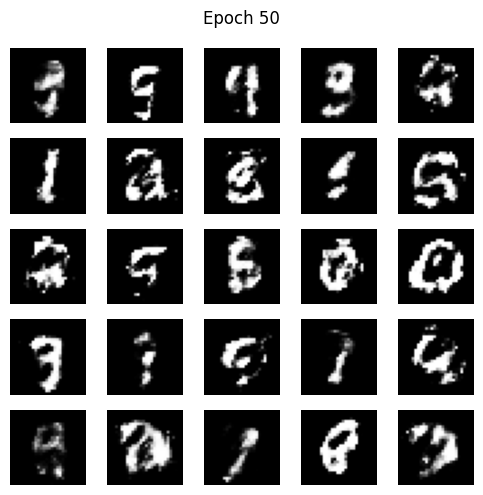

In [7]:
c_losses = []   
g_losses = []

for epoch in range(epochs):
    epoch_c_loss = 0
    epoch_g_loss = 0
    num_batches  = 0

    for i, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        batch_sz  = real_imgs.size(0)
        for _ in range(n_critic):
            optimizer_C.zero_grad()

            # sample noise → fake images
            z = torch.randn(batch_sz, latent_dim).to(device)
            fake_imgs = generator(z).detach()  

            # wasserstein Critic loss
            c_loss = -torch.mean(critic(real_imgs)) + torch.mean(critic(fake_imgs))
            c_loss.backward()
            optimizer_C.step()


            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)


        optimizer_G.zero_grad()

        z = torch.randn(batch_sz, latent_dim).to(device)
        fake_imgs = generator(z)

        # gen loss
        g_loss = -torch.mean(critic(fake_imgs))
        g_loss.backward()
        optimizer_G.step()

        epoch_c_loss += c_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches  += 1

    # Average 
    avg_c = epoch_c_loss / num_batches
    avg_g = epoch_g_loss / num_batches
    c_losses.append(avg_c)
    g_losses.append(avg_g)

    print(f"Epoch [{epoch+1}/{epochs}]  Critic Loss: {avg_c:.4f}  Gen Loss: {avg_g:.4f}")

    if (epoch + 1) % 10 == 0:
        generator.eval()
        with torch.no_grad():
            z_vis = torch.randn(25, latent_dim).to(device)
            show_images(generator(z_vis), epoch + 1)
        generator.train()

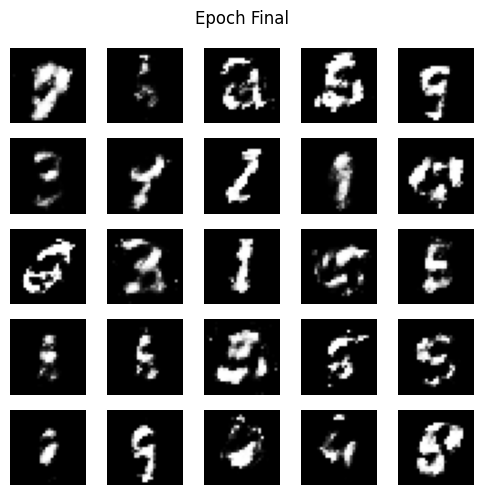

In [9]:
generator.eval()
with torch.no_grad():
    z = torch.randn(25, latent_dim).to(device)
    generated_imgs = generator(z)

show_images(generated_imgs, "Final")

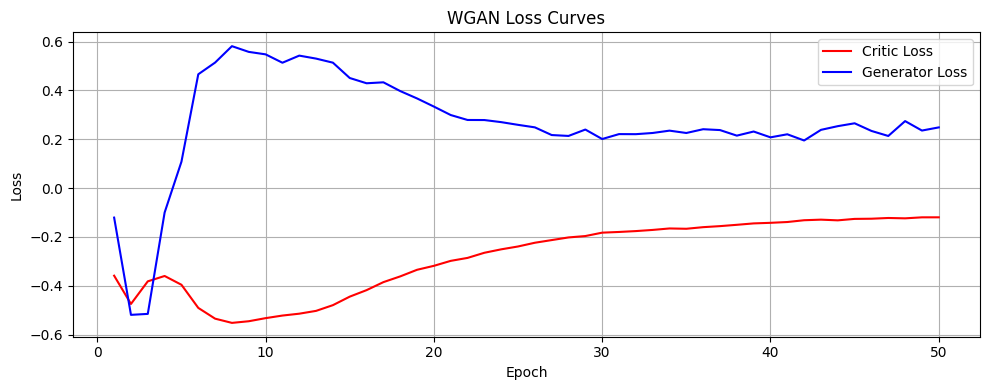

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, epochs + 1), c_losses, label='Critic Loss',    color='red')
plt.plot(range(1, epochs + 1), g_losses, label='Generator Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('WGAN Loss Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()